In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv("nigeria_acled.csv", parse_dates=['TimeFK_Event_Date'])
df_orig = df.copy()
# df.shape
# df.head()

Uncomment cell below to filter by Admin1:

In [3]:
# admin = input('Enter Admin1 of interest: ')
# df = df[df['ACLED_Admin1']==admin]

### Isolation Forest  
May not be ideal for time series?

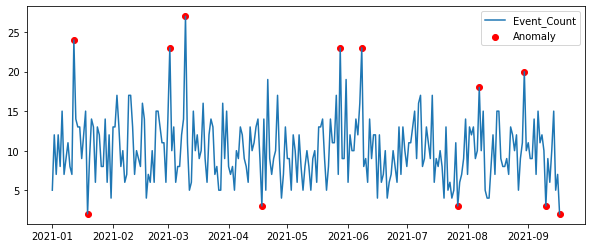

In [4]:
dailydata = pd.DataFrame(df.groupby('TimeFK_Event_Date').size(), columns=['Event_Count'])

model = IsolationForest(contamination=0.05)
dailydata['anomaly'] = model.fit_predict(dailydata)

anomalies = dailydata[dailydata['anomaly']==-1]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(dailydata.index, dailydata.Event_Count, label='Event_Count')
ax.scatter(anomalies.index, anomalies.Event_Count, color='red', label='Anomaly')
plt.legend()
plt.show()

### Moving Average

In [8]:
daily = pd.DataFrame(df.groupby('TimeFK_Event_Date').size(), columns=['Event_Count'])

# Simple Moving Average
daily['MA'] = daily.iloc[:,0].rolling(window=10).mean()
daily['Upper'] = daily['MA'] + 5
daily['Lower'] = daily['MA'] - 5

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily.index, y=daily['Lower'],fill=None, 
                         mode='lines', line_color='green', showlegend=False))
fig.add_trace(go.Scatter(x=daily.index, y=daily['Upper'], fill='tonexty', 
                         mode='lines', line_color='green', name='Predicted Interval'))
fig.add_trace(go.Scatter(x=daily.index, y=daily['Event_Count'], fill=None, 
                         mode='markers', marker=dict(color='blue'), name='Actual'))
fig.update_layout(
    xaxis_title='Event Date', 
    yaxis_title='Event Count'
)

fig.show()

### HDBSCAN